# DDoS Detection

Az események (events) halmaz szerkezete:

- `Attack ID`: egyedi esemény azonosító
- `Card`: hálózati kártya azonosító
- `Victim IP`: anonimizált cél IP (a teljes adathalmazon egyedi)
- `Port number`: cél port száma
- `Attack code`: a legfontosabb összetevő jellege
- `Detect count`: az esemény összetevőinek száma
- `Significant flag`: a DDoS detektor belső használatú flagje (számunkra irreleváns)
- `Packet speed`: csomagráta (pps)
- `Data speed`: adatráta (bps)
- `Avg packet len`: átlagos csomaghossz (byte)
- `Avg source IP count`: a komponensekben érintett IP-k átlagos száma
- `Start time`: az esemény kezdetének ideje (dátummal)
- `End time`: az esemény végének ideje (dátummal)
- `Whitelist flag`: a DDoS detektor belső használatú flagje (számunkra irreleváns)
- `Type`: az esemény kategóriája (aminként a DDoS detektor felcimkézte)

Az összetevők (components) halmaz szerkezete:

- `Attack ID`: egyedi esemény azonosító
- `Detect count`: az összetevő azonosító száma (az eseményen belül)
- `Card`: hálózati kártya azonosító
- `Victim IP`: anonimizált cél IP
- `Port number`: cél port száma
- `Attack code`: az összetevő jellege
- `Significant flag`: a DDoS detektor belső használatú flagje (számunkra irreleváns)
- `Packet speed`: csomagráta (pps)
- `Data speed`: adatráta (bps)
- `Avg packet len`: átlagos csomaghossz (byte)
- `Source IP count`: forrás IP-k száma
- `Time`: az esemény összetevőjének kezdő ideje (dátummal)

The task is to predict `Type` and possibly `Attack code`. 

## Data Preprocessing

Cleans and merges data from multiple recordings (events and components)

- parse datetimes
- ensure data quality: duplicates, nulls, invalid ranges, and key consistency (`Attack ID` between events/components).
- remove useless features: `Victim IP`, `Significant flag`, `Whitelist flag`

Feature engineering:

- convert start and end times to `event_duration`
- create `day_of_week` and `hour_of_day` features
- remove `Packet speed`/`Data speed` redundancy
- aggregate components by `AttackID`
- for clarity, every feature's name should be snake_case

Creates train, validation and test split from the merged data.

Persists preprocessed data in ddos-detection/data_preprocessed/ using the train/validation/test split.

In [12]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

EVENTS_COLS = [
    "Attack ID", "Card", "Victim IP", "Port number", "Attack code", "Detect count",
    "Packet speed", "Data speed", "Avg packet len", "Avg source IP count",
    "Start time", "End time", "Type"
 ]
COMP_COLS = [
    "Attack ID", "Detect count", "Card", "Victim IP", "Port number", "Attack code",
    "Packet speed", "Data speed", "Avg packet len", "Source IP count", "Time"
 ]

def _to_snake_case(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")


def _safe_mode(series: pd.Series):
    mode_values = series.mode(dropna=True)
    return mode_values.iloc[0] if not mode_values.empty else np.nan


def _log_step(verbose, label, before_rows, after_rows):
    if verbose:
        removed = before_rows - after_rows
        print(f"[cleaning] {label}: {before_rows} -> {after_rows} (removed: {removed})")


def preprocess(
    recordings,
    data_dir="./ddos-detection/data_raw",
    out_dir="./ddos-detection/data_preprocessed",
    test_size=0.20,
    val_size=0.10,
    random_state=42,
    verbose=True,
):
    """
    Build a clean, merged dataset from events/components, split it and persist CSV files.
    val_size is interpreted on full dataset size (not on the post-test remainder).
    """
    events_frames = []
    comp_frames = []

    data_dir = Path(data_dir)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if verbose:
        print("[load] recordings:", list(recordings))

    for recording in recordings:
        components_path = data_dir / f"{recording}_components.csv"
        events_path = data_dir / f"{recording}_events.csv"

        events = pd.read_csv(events_path, usecols=EVENTS_COLS)
        components = pd.read_csv(components_path, usecols=COMP_COLS)

        if verbose:
            print(f"[load] {recording}: events={len(events)}, components={len(components)}")

        events["recording"] = recording
        components["recording"] = recording

        events_frames.append(events)
        comp_frames.append(components)

    events = pd.concat(events_frames, ignore_index=True)
    components = pd.concat(comp_frames, ignore_index=True)

    if verbose:
        print(f"[load] combined: events={len(events)}, components={len(components)}")

    # Remove exact duplicates early.
    before = len(events)
    events = events.drop_duplicates().copy()
    _log_step(verbose, "events duplicate removal", before, len(events))

    before = len(components)
    components = components.drop_duplicates().copy()
    _log_step(verbose, "components duplicate removal", before, len(components))

    # Parse datetimes and remove rows with invalid dates.
    events["Start time"] = pd.to_datetime(events["Start time"], errors="coerce")
    events["End time"] = pd.to_datetime(events["End time"], errors="coerce")
    components["Time"] = pd.to_datetime(components["Time"], errors="coerce")

    before = len(events)
    events = events.dropna(subset=["Start time", "End time", "Attack ID", "Type"]).copy()
    _log_step(verbose, "events drop missing required fields", before, len(events))

    before = len(components)
    components = components.dropna(subset=["Time", "Attack ID"]).copy()
    _log_step(verbose, "components drop missing required fields", before, len(components))

    # Keep only positive-duration events.
    before = len(events)
    events = events.loc[events["End time"] >= events["Start time"]].copy()
    _log_step(verbose, "events invalid time range filter", before, len(events))

    # Keep only components that belong to known event IDs.
    valid_attack_ids = set(events["Attack ID"].unique())
    before = len(components)
    components = components.loc[components["Attack ID"].isin(valid_attack_ids)].copy()
    _log_step(verbose, "components key consistency filter", before, len(components))

    # Remove irrelevant/high-cardinality fields.
    events = events.drop(columns=["Victim IP"], errors="ignore")
    components = components.drop(columns=["Victim IP"], errors="ignore")

    # Feature engineering on event timestamps.
    events["event_duration_sec"] = (events["End time"] - events["Start time"]).dt.total_seconds()
    events["day_of_week"] = events["Start time"].dt.dayofweek
    events["hour_of_day"] = events["Start time"].dt.hour

    # Remove redundant low-information speed feature.
    events = events.drop(columns=["Data speed"], errors="ignore")
    components = components.drop(columns=["Data speed"], errors="ignore")

    # Aggregate components to attack level.
    comp_agg = (
        components.groupby("Attack ID", as_index=False)
        .agg(
            comp_row_count=("Detect count", "size"),
            comp_detect_count_max=("Detect count", "max"),
            comp_packet_speed_mean=("Packet speed", "mean"),
            comp_packet_speed_max=("Packet speed", "max"),
            comp_avg_packet_len_mean=("Avg packet len", "mean"),
            comp_source_ip_count_mean=("Source IP count", "mean"),
            comp_source_ip_count_max=("Source IP count", "max"),
            comp_attack_code_mode=("Attack code", _safe_mode),
            comp_card_mode=("Card", _safe_mode),
            comp_first_time=("Time", "min"),
            comp_last_time=("Time", "max"),
        )
        .copy()
    )
    comp_agg["comp_duration_sec"] = (comp_agg["comp_last_time"] - comp_agg["comp_first_time"]).dt.total_seconds()

    # Event-level safety deduplication by Attack ID.
    before = len(events)
    events = events.sort_values("Start time").drop_duplicates(subset=["Attack ID"], keep="last").copy()
    _log_step(verbose, "events duplicate attack_id resolution", before, len(events))

    # Merge event and aggregated component features.
    merged = events.merge(comp_agg, on="Attack ID", how="left")

    # Fill numeric NaNs after merge (attacks without component rows).
    numeric_cols = merged.select_dtypes(include=["number"]).columns
    merged[numeric_cols] = merged[numeric_cols].fillna(0)

    # Final naming standardization to snake_case.
    merged.columns = [_to_snake_case(c) for c in merged.columns]

    if verbose:
        print(f"[result] merged rows={len(merged)}, columns={merged.shape[1]}")

    # Train/validation/test split.
    target_col = "type"
    y = merged[target_col]
    stratify_y = y if y.nunique() > 1 and y.value_counts().min() >= 2 else None

    train_val_df, test_df = train_test_split(
        merged,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_y,
    )

    val_ratio_in_train_val = val_size / (1.0 - test_size)
    y_train_val = train_val_df[target_col]
    stratify_train_val = y_train_val if y_train_val.nunique() > 1 and y_train_val.value_counts().min() >= 2 else None

    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_ratio_in_train_val,
        random_state=random_state,
        stratify=stratify_train_val,
    )

    # Persist splits and full merged table.
    merged.to_csv(out_dir / "all_data.csv", index=False)
    train_df.to_csv(out_dir / "train.csv", index=False)
    val_df.to_csv(out_dir / "validation.csv", index=False)
    test_df.to_csv(out_dir / "test.csv", index=False)

    print(f"Saved: {out_dir / 'all_data.csv'} ({len(merged)} rows)")
    print(f"Saved: {out_dir / 'train.csv'} ({len(train_df)} rows)")
    print(f"Saved: {out_dir / 'validation.csv'} ({len(val_df)} rows)")
    print(f"Saved: {out_dir / 'test.csv'} ({len(test_df)} rows)")

    return {
        "all": merged,
        "train": train_df,
        "validation": val_df,
        "test": test_df,
    }

In [5]:
result = preprocess(["SCLDDoS2024_SetA"])
for split_name, split_df in result.items():
    print(f"{split_name}: {split_df.shape}")

[load] recordings: ['SCLDDoS2024_SetA']
[load] SCLDDoS2024_SetA: events=134770, components=586642
[load] combined: events=134770, components=586642
[cleaning] events duplicate removal: 134770 -> 134770 (removed: 0)
[cleaning] components duplicate removal: 586642 -> 586642 (removed: 0)
[cleaning] events drop missing required fields: 134770 -> 134766 (removed: 4)
[cleaning] components drop missing required fields: 586642 -> 586642 (removed: 0)
[cleaning] events invalid time range filter: 134766 -> 134766 (removed: 0)
[cleaning] components key consistency filter: 586642 -> 586636 (removed: 6)
[cleaning] events duplicate attack_id resolution: 134766 -> 134766 (removed: 0)
[result] merged rows=134766, columns=27
Saved: ddos-detection\data_preprocessed\all_data.csv (134766 rows)
Saved: ddos-detection\data_preprocessed\train.csv (94335 rows)
Saved: ddos-detection\data_preprocessed\validation.csv (13477 rows)
Saved: ddos-detection\data_preprocessed\test.csv (26954 rows)
all: (134766, 27)
train

## Data Visualization

### Class Distribution and Imbalance

Counts and ratio of different event types showing class imbalance

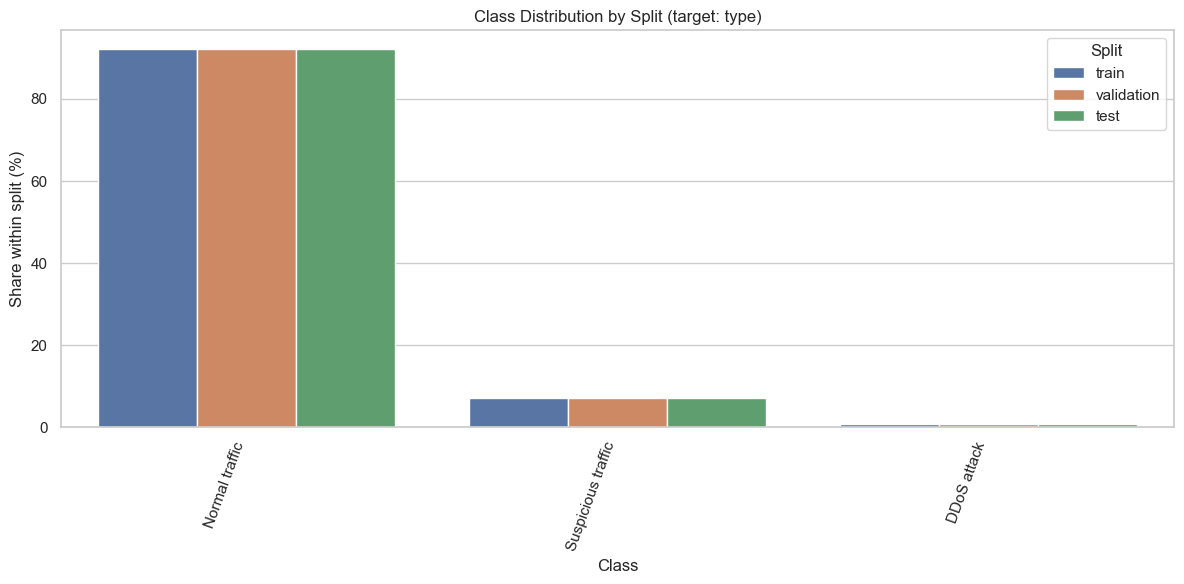

split,class,test,train,validation
1,Normal traffic,92.108778,92.110033,92.112488
2,Suspicious traffic,7.204868,7.201993,7.204868
0,DDoS attack,0.686355,0.687974,0.682645


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


def visualize_class_imbalance(splits, target_col="type", top_n=20):
    rows = []
    split_order = ["train", "validation", "test"]

    for split_name in split_order:
        if split_name not in splits:
            raise KeyError(f"Missing split: {split_name}")

        split_df = splits[split_name]
        if target_col not in split_df.columns:
            raise KeyError(f"Column '{target_col}' is not present in {split_name}")

        counts = split_df[target_col].value_counts(dropna=False)
        total = len(split_df)

        for class_name, count in counts.items():
            rows.append(
                {
                    "split": split_name,
                    "class": str(class_name),
                    "count": int(count),
                    "percentage": (count / total) * 100.0 if total > 0 else 0.0,
                }
            )

    dist_df = pd.DataFrame(rows)

    class_order = (
        dist_df.groupby("class", as_index=False)["count"]
        .sum()
        .sort_values("count", ascending=False)
    )
    if top_n is not None and top_n > 0:
        class_order = class_order.head(top_n)

    class_order = class_order["class"].tolist()
    plot_df = dist_df[dist_df["class"].isin(class_order)].copy()

    plt.figure(figsize=(max(12, len(class_order) * 0.55), 6))
    ax = sns.barplot(
        data=plot_df,
        x="class",
        y="percentage",
        hue="split",
        hue_order=split_order,
        order=class_order,
    )

    ax.set_title("Class Distribution by Split (target: type)")
    ax.set_xlabel("Class")
    ax.set_ylabel("Share within split (%)")
    plt.xticks(rotation=70, ha="right")
    plt.legend(title="Split")
    plt.tight_layout()
    plt.show()

    summary = (
        plot_df.pivot_table(
            index="class",
            columns="split",
            values="percentage",
            aggfunc="sum",
            fill_value=0,
        )
        .reset_index()
        .sort_values("train", ascending=False)
    )
    return summary


imbalance_summary = visualize_class_imbalance(result, target_col="type", top_n=20)
imbalance_summary.head(20)

### Feature Distributions

Box-and-whisker plots comparing numeric feature distributions across event types (`type`).

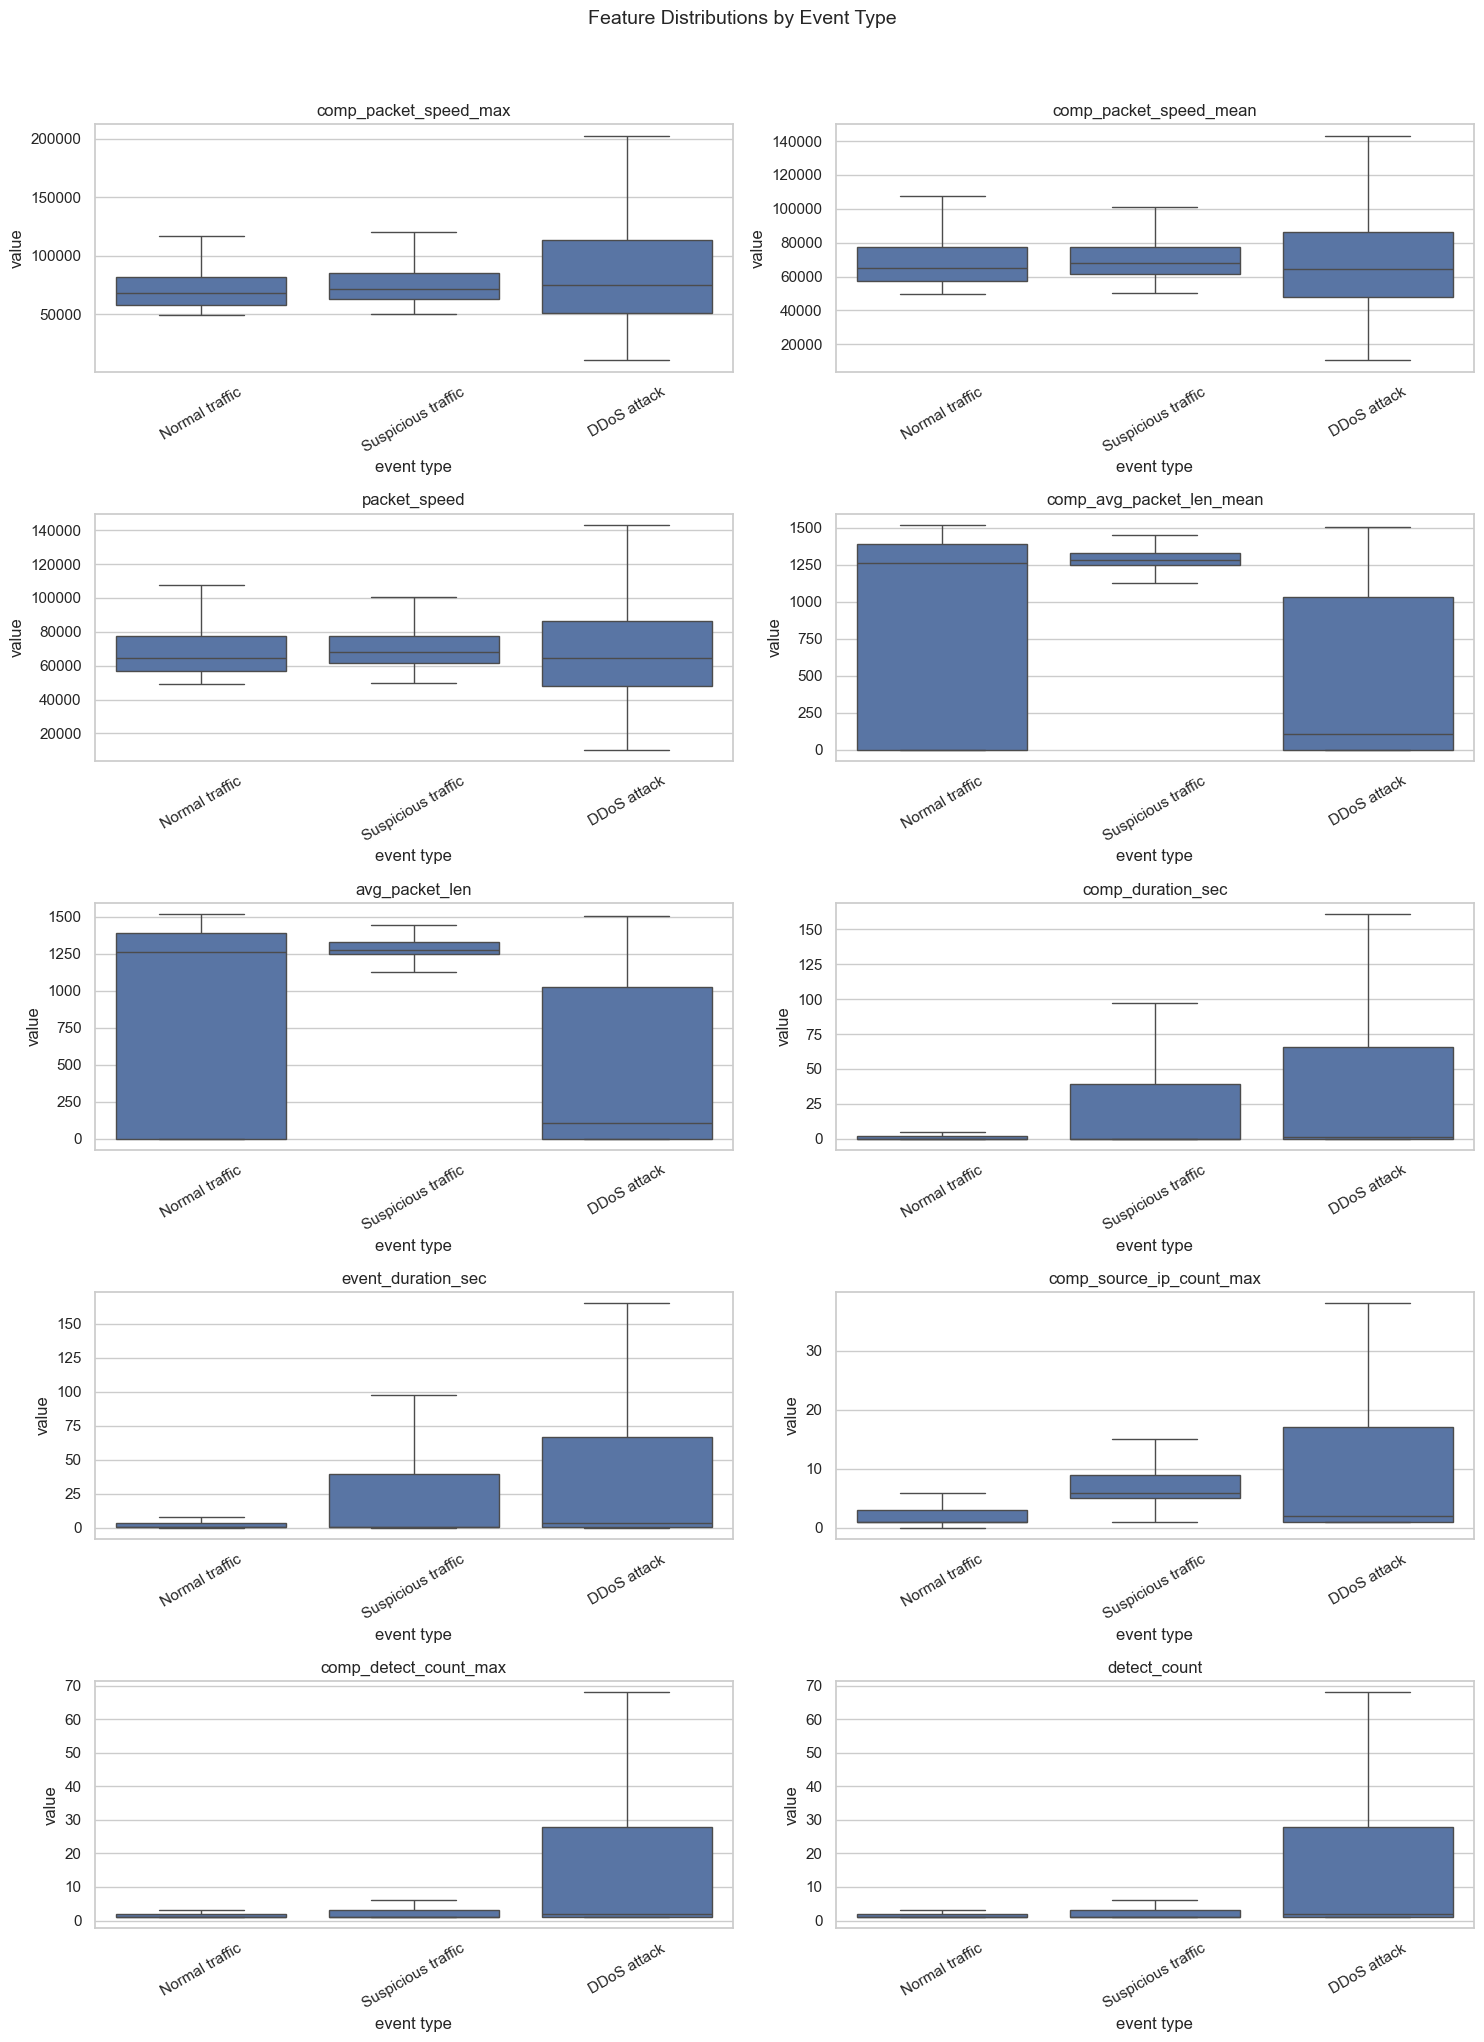

Plotted features:
- comp_packet_speed_max
- comp_packet_speed_mean
- packet_speed
- comp_avg_packet_len_mean
- avg_packet_len
- comp_duration_sec
- event_duration_sec
- comp_source_ip_count_max
- comp_detect_count_max
- detect_count

Class counts:
- Normal traffic: 124133
- Suspicious traffic: 9707
- DDoS attack: 926


In [10]:
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


def visualize_feature_distributions_by_event_type(
    df,
    target_col="type",
    max_features=10,
    sample_per_class=15000,
    exclude_cols=None,
):
    """
    Draw box-and-whisker distributions for numeric features grouped by event type.
    """
    if target_col not in df.columns:
        raise KeyError(f"Column '{target_col}' is missing from the dataset.")

    if exclude_cols is None:
        exclude_cols = {
            target_col,
            "attack_id",
            "recording",
            "start_time",
            "end_time",
            "comp_first_time",
            "comp_last_time",
            "port_number",
        }

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

    if not numeric_cols:
        raise ValueError("No numeric feature columns found for plotting.")

    # Keep the most variable features for readable multi-plot output.
    ranked = df[numeric_cols].std(numeric_only=True).sort_values(ascending=False)
    selected_features = ranked.head(max_features).index.tolist()

    class_counts = df[target_col].value_counts(dropna=False)
    class_order = class_counts.index.astype(str).tolist()

    sampled_frames = []
    for class_name in class_order:
        class_df = df[df[target_col].astype(str) == class_name]
        n = min(len(class_df), sample_per_class)
        sampled = class_df.sample(n=n, random_state=42).copy() if len(class_df) > n else class_df.copy()
        sampled[target_col] = sampled[target_col].astype(str)
        sampled_frames.append(sampled[[target_col] + selected_features])

    combined = pd.concat(sampled_frames, ignore_index=True)

    n_features = len(selected_features)
    n_cols = 2
    n_rows = math.ceil(n_features / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4 * n_rows, 6)))
    if hasattr(axes, "flatten"):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, feature in enumerate(selected_features):
        ax = axes[i]
        sns.boxplot(
            data=combined,
            x=target_col,
            y=feature,
            order=class_order,
            showfliers=False,
            ax=ax,
        )
        ax.set_title(feature)
        ax.set_xlabel("event type")
        ax.set_ylabel("value")
        ax.tick_params(axis="x", rotation=30)

    for j in range(n_features, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Feature Distributions by Event Type", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print("Plotted features:")
    for f in selected_features:
        print(f"- {f}")

    print("\nClass counts:")
    for class_name, count in class_counts.items():
        print(f"- {class_name}: {count}")

    return selected_features


selected_feature_distributions = visualize_feature_distributions_by_event_type(
    result["all"],
    target_col="type",
    max_features=10,
    sample_per_class=15000,
)

### Correlation Matrix

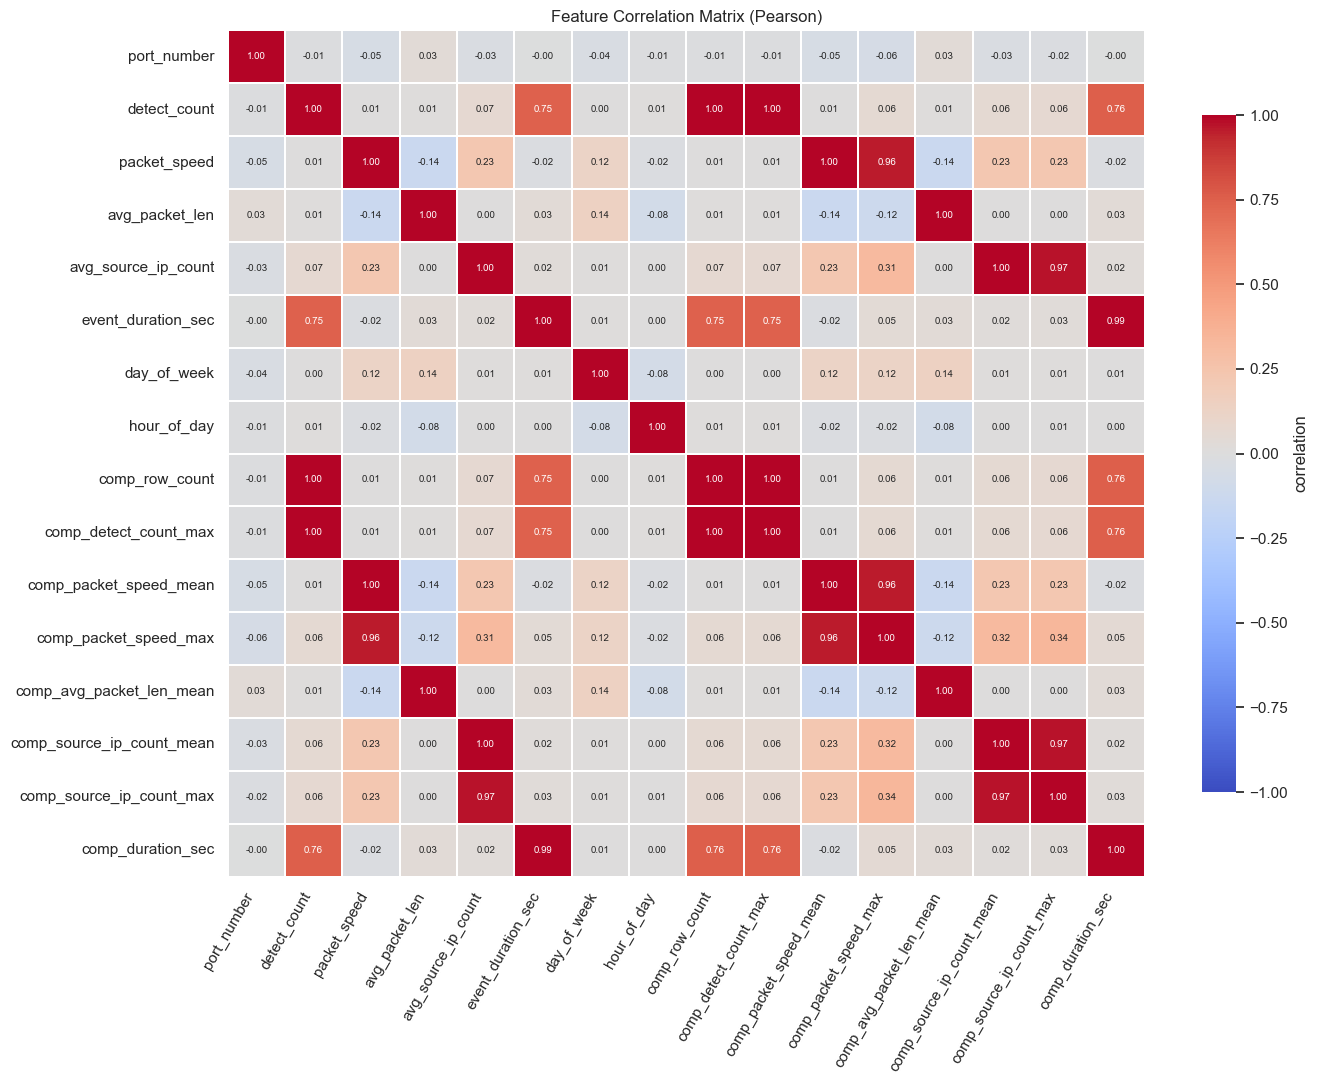

,port_number,detect_count,packet_speed,avg_packet_len,avg_source_ip_count,event_duration_sec,day_of_week,hour_of_day,comp_row_count,comp_detect_count_max,comp_packet_speed_mean,comp_packet_speed_max,comp_avg_packet_len_mean,comp_source_ip_count_mean,comp_source_ip_count_max,comp_duration_sec
port_number,1.000000,-0.009200,-0.054153,0.034909,-0.026163,-0.000808,-0.037836,-0.010478,-0.009506,-0.009190,-0.054150,-0.058886,0.034859,-0.025932,-0.020938,-0.000567
detect_count,-0.009200,1.000000,0.007128,0.008209,0.065863,0.747399,0.004483,0.010144,0.997203,0.999982,0.007050,0.056779,0.008873,0.061766,0.063913,0.756439
packet_speed,-0.054153,0.007128,1.000000,-0.136807,0.227492,-0.018216,0.124510,-0.020788,0.007163,0.007123,0.999999,0.957898,-0.136815,0.228862,0.233323,-0.016928
avg_packet_len,0.034909,0.008209,-0.136807,1.000000,0.003329,0.033588,0.141938,-0.082365,0.008555,0.008185,-0.136811,-0.117643,0.999996,0.003779,0.004133,0.032649
avg_source_ip_count,-0.026163,0.065863,0.227492,0.003329,1.000000,0.024000,0.011485,0.003745,0.066230,0.065861,0.227486,0.314455,0.003426,0.999681,0.971824,0.024178


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")


def plot_feature_correlation_matrix(
    df,
    target_col="type",
    method="pearson",
    figsize=(14, 11),
    exclude_cols=None,
):
    """
    Plot correlation matrix for numeric features only.
    """
    if exclude_cols is None:
        exclude_cols = {
            target_col,
            "attack_id",
            "recording",
            "start_time",
            "end_time",
            "comp_first_time",
            "comp_last_time",
        }

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in exclude_cols]

    if len(feature_cols) < 2:
        raise ValueError("Need at least two numeric feature columns for correlation matrix.")

    corr = df[feature_cols].corr(method=method)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=False,
        linewidths=0.2,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        cbar_kws={"shrink": 0.8, "label": "correlation"},
    )
    plt.title(f"Feature Correlation Matrix ({method.capitalize()})")
    plt.xticks(rotation=60, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return corr


feature_correlation_matrix = plot_feature_correlation_matrix(
    result["all"],
    target_col="type",
    method="pearson",
)

## Data Augmentation

### Baseline Model

Smallish Random Forest Classifier which provides a baseline to test later models against and to measure the effectiveness of data augmentation. 

In [13]:
from sklearn.ensemble import RandomForestClassifier


def build_baseline_model(random_state=42):
    """Return the baseline RandomForest model definition (untrained)."""
    return RandomForestClassifier(
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=random_state,
        n_jobs=-1,
    )


baseline_model = build_baseline_model()
baseline_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",18
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Synthetic Samples

Creates synthetic samples using the Synthetic Minority Over-sampling Technique.

In [9]:
from pathlib import Path

import pandas as pd
from imblearn.over_sampling import SMOTE


def generate_smote_data(
    preprocessed_dir="./ddos-detection/data_preprocessed",
    out_dir="./ddos-detection/data_augmented",
    target_col="type",
    drop_cols=None,
):
    if drop_cols is None:
        drop_cols = [
            target_col,
            "attack_id",
            "recording",
            "start_time",
            "end_time",
            "comp_first_time",
            "comp_last_time",
            "attack_code",
            "comp_attack_code_mode",
        ]

    in_path = Path(preprocessed_dir)
    train_df = pd.read_csv(in_path / "train.csv")
    val_df = pd.read_csv(in_path / "validation.csv")
    test_df = pd.read_csv(in_path / "test.csv")

    def split_xy(df):
        usable_drop = [c for c in drop_cols if c in df.columns]
        X = df.drop(columns=usable_drop).copy()
        y = df[target_col].copy()
        return X, y

    X_train_raw, y_train = split_xy(train_df)
    X_val_raw, y_val = split_xy(val_df)
    X_test_raw, y_test = split_xy(test_df)

    # One-hot encode jointly so matrices are aligned.
    combined_X = pd.concat([X_train_raw, X_val_raw, X_test_raw], axis=0, ignore_index=True)
    categorical_cols = combined_X.select_dtypes(include=["object", "string", "category", "bool"]).columns
    combined_X = pd.get_dummies(combined_X, columns=categorical_cols)

    n_train = len(X_train_raw)
    n_val = len(X_val_raw)
    X_train = combined_X.iloc[:n_train].reset_index(drop=True)
    X_val = combined_X.iloc[n_train:n_train + n_val].reset_index(drop=True)
    X_test = combined_X.iloc[n_train + n_val:].reset_index(drop=True)

    # Use validation data in training pool (model selection does not require separate val split).
    X_train_pool = pd.concat([X_train, X_val], ignore_index=True)
    y_train_pool = pd.concat([y_train.reset_index(drop=True), y_val.reset_index(drop=True)], ignore_index=True)

    class_counts_before = y_train_pool.value_counts().sort_index()
    print("Train-pool class counts before SMOTE:")
    print(class_counts_before)

    minority_count = class_counts_before.min()
    if minority_count <= 1:
        raise ValueError("SMOTE requires at least 2 samples in the minority class.")

    k_neighbors = min(5, minority_count - 1)
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_pool, y_train_pool)

    class_counts_after = pd.Series(y_train_smote).value_counts().sort_index()
    print("\nTrain-pool class counts after SMOTE:")
    print(class_counts_after)

    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    train_aug_df = pd.DataFrame(X_train_smote, columns=X_train_pool.columns)
    train_aug_df[target_col] = y_train_smote

    val_encoded_df = X_val.copy()
    val_encoded_df[target_col] = y_val.values

    test_encoded_df = X_test.copy()
    test_encoded_df[target_col] = y_test.values

    all_aug_df = pd.concat([train_aug_df, val_encoded_df, test_encoded_df], ignore_index=True)

    train_aug_df.to_csv(out_path / "train.csv", index=False)
    val_encoded_df.to_csv(out_path / "validation.csv", index=False)
    test_encoded_df.to_csv(out_path / "test.csv", index=False)
    all_aug_df.to_csv(out_path / "all_data.csv", index=False)

    print(f"\nSaved: {out_path / 'all_data.csv'} ({len(all_aug_df)} rows)")
    print(f"Saved: {out_path / 'train.csv'} ({len(train_aug_df)} rows)")
    print(f"Saved: {out_path / 'validation.csv'} ({len(val_encoded_df)} rows)")
    print(f"Saved: {out_path / 'test.csv'} ({len(test_encoded_df)} rows)")

    return {
        "train": train_aug_df,
        "validation": val_encoded_df,
        "test": test_encoded_df,
        "all": all_aug_df,
    }


augmented_result = generate_smote_data(
    preprocessed_dir="./ddos-detection/data_preprocessed",
    out_dir="./ddos-detection/data_augmented",
    target_col="type",
)

Train-pool class counts before SMOTE:
type
DDoS attack             741
Normal traffic        99306
Suspicious traffic     7765
Name: count, dtype: int64

Train-pool class counts after SMOTE:
type
DDoS attack           99306
Normal traffic        99306
Suspicious traffic    99306
Name: count, dtype: int64

Saved: ddos-detection\data_augmented\all_data.csv (338349 rows)
Saved: ddos-detection\data_augmented\train.csv (297918 rows)
Saved: ddos-detection\data_augmented\validation.csv (13477 rows)
Saved: ddos-detection\data_augmented\test.csv (26954 rows)


In [10]:
from pathlib import Path

import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def evaluate_test(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
    }


def prepare_preprocessed_trainpool_and_test(
    base_dir="./ddos-detection/data_preprocessed",
    target_col="type",
    drop_cols=None,
):
    if drop_cols is None:
        drop_cols = [
            target_col,
            "attack_id",
            "recording",
            "start_time",
            "end_time",
            "comp_first_time",
            "comp_last_time",
            "attack_code",
            "comp_attack_code_mode",
        ]

    base_path = Path(base_dir)
    train_df = pd.read_csv(base_path / "train.csv")
    val_df = pd.read_csv(base_path / "validation.csv")
    test_df = pd.read_csv(base_path / "test.csv")

    def split_xy(df):
        usable_drop = [c for c in drop_cols if c in df.columns]
        X = df.drop(columns=usable_drop).copy()
        y = df[target_col].copy()
        return X, y

    X_train_raw, y_train = split_xy(train_df)
    X_val_raw, y_val = split_xy(val_df)
    X_test_raw, y_test = split_xy(test_df)

    # Build aligned feature space across train/validation/test.
    combined_X = pd.concat([X_train_raw, X_val_raw, X_test_raw], axis=0, ignore_index=True)
    categorical_cols = combined_X.select_dtypes(include=["object", "string", "category", "bool"]).columns
    combined_X = pd.get_dummies(combined_X, columns=categorical_cols)

    n_train = len(X_train_raw)
    n_val = len(X_val_raw)
    X_train = combined_X.iloc[:n_train].reset_index(drop=True)
    X_val = combined_X.iloc[n_train:n_train + n_val].reset_index(drop=True)
    X_test = combined_X.iloc[n_train + n_val:].reset_index(drop=True)

    X_train_pool = pd.concat([X_train, X_val], ignore_index=True)
    y_train_pool = pd.concat([y_train.reset_index(drop=True), y_val.reset_index(drop=True)], ignore_index=True)

    return X_train_pool, y_train_pool, X_test, y_test.reset_index(drop=True)


def load_augmented_trainpool_and_test(
    base_dir="./ddos-detection/data_augmented",
    target_col="type",
):
    base_path = Path(base_dir)
    train_aug_df = pd.read_csv(base_path / "train.csv")
    test_aug_df = pd.read_csv(base_path / "test.csv")

    X_train_aug = train_aug_df.drop(columns=[target_col]).copy()
    y_train_aug = train_aug_df[target_col].copy()
    X_test_aug = test_aug_df.drop(columns=[target_col]).copy()
    y_test_aug = test_aug_df[target_col].copy()

    X_test_aug = X_test_aug.reindex(columns=X_train_aug.columns, fill_value=0)
    return X_train_aug, y_train_aug, X_test_aug, y_test_aug


if "build_baseline_model" not in globals():
    raise RuntimeError("Run cell 11 first to define build_baseline_model().")

# Preprocessed baseline: train on train+validation, evaluate on test only.
X_train_pre, y_train_pre, X_test_pre, y_test_pre = prepare_preprocessed_trainpool_and_test()
preprocessed_model = build_baseline_model(random_state=42)
preprocessed_model.fit(X_train_pre, y_train_pre)
preprocessed_metrics = evaluate_test(preprocessed_model, X_test_pre, y_test_pre)

# Augmented baseline: train on SMOTE-augmented train pool, evaluate on test only.
X_train_aug, y_train_aug, X_test_aug, y_test_aug = load_augmented_trainpool_and_test()
augmented_model = build_baseline_model(random_state=42)
augmented_model.fit(X_train_aug, y_train_aug)
augmented_metrics = evaluate_test(augmented_model, X_test_aug, y_test_aug)

comparison_df = pd.DataFrame(
    [
        {"data_source": "preprocessed", **preprocessed_metrics},
        {"data_source": "augmented_smote", **augmented_metrics},
    ]
 )

delta_row = {
    "delta_accuracy": augmented_metrics["accuracy"] - preprocessed_metrics["accuracy"],
    "delta_balanced_accuracy": augmented_metrics["balanced_accuracy"] - preprocessed_metrics["balanced_accuracy"],
    "delta_f1_macro": augmented_metrics["f1_macro"] - preprocessed_metrics["f1_macro"],
}
delta_df = pd.DataFrame([delta_row])

print("Test-set comparison (trained on train+validation):")
display(comparison_df)

print("\nDelta (augmented - preprocessed):")
delta_df

Test-set comparison (trained on train+validation):


,data_source,accuracy,balanced_accuracy,f1_macro
0,preprocessed,0.946613,0.865059,0.825234
1,augmented_smote,0.939786,0.868064,0.784145



Delta (augmented - preprocessed):


,delta_accuracy,delta_balanced_accuracy,delta_f1_macro
0,-0.006826,0.003005,-0.041089


Saved: ddos-detection\data_preprocessed_setb\all_data.csv (130000 rows)
Saved: ddos-detection\data_preprocessed_setb\train.csv (91000 rows)
Saved: ddos-detection\data_preprocessed_setb\validation.csv (13000 rows)
Saved: ddos-detection\data_preprocessed_setb\test.csv (26000 rows)
SetB holdout evaluation (threshold-tuned):


,train_source,accuracy,balanced_accuracy,f1_macro
0,SetA preprocessed,0.932831,0.496743,0.526290
1,SetA augmented_smote,0.868346,0.484076,0.405177



Delta on SetB (augmented - preprocessed):


,delta_accuracy,delta_balanced_accuracy,delta_f1_macro
0,-0.064485,-0.012667,-0.121114



Confusion matrix: SetA preprocessed -> SetB


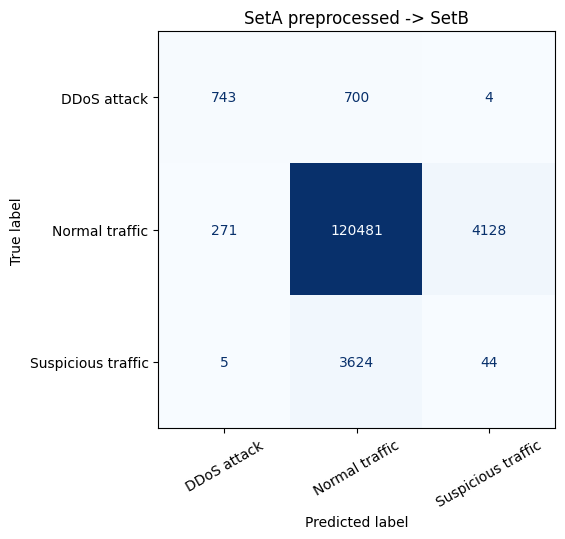

Confusion matrix: SetA augmented_smote -> SetB


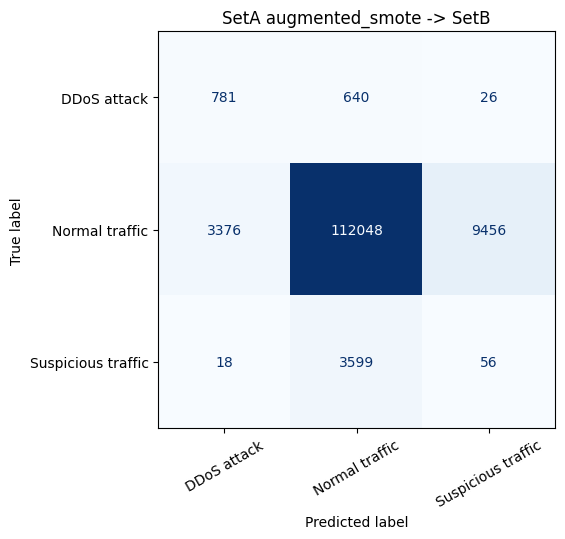

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
 )


def _split_xy_no_leak(df, target_col="type"):
    drop_cols = [
        target_col,
        "attack_id",
        "recording",
        "start_time",
        "end_time",
        "comp_first_time",
        "comp_last_time",
        "attack_code",
        "comp_attack_code_mode",
    ]
    usable_drop = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=usable_drop).copy()
    y = df[target_col].copy()
    return X, y


def _metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }


def _predict_with_thresholds(model, X, thresholds=None):
    if thresholds is None:
        return model.predict(X)

    proba = model.predict_proba(X)
    classes = model.classes_
    threshold_arr = pd.Series([thresholds.get(c, 1.0) for c in classes], index=classes).values
    adjusted = proba / threshold_arr
    pred_idx = adjusted.argmax(axis=1)
    return classes[pred_idx]


def _plot_confusion(y_true, y_pred, title):
    labels = sorted(pd.Series(y_true).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=30, colorbar=False, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# Best no-SMOTE threshold config from tuning.
THRESHOLDS = {
    "Normal traffic": 1.0,
    "Suspicious traffic": 0.7,
    "DDoS attack": 0.6,
}

# 1) Preprocess unseen SetB into a separate output directory.
setb_result = preprocess(
    ["SCLDDoS2024_SetB"],
    out_dir="./ddos-detection/data_preprocessed_setb",
    verbose=False,
 )
setb_all = setb_result["all"].copy()
X_setb_raw, y_setb = _split_xy_no_leak(setb_all, target_col="type")

# 2) Train model on SetA preprocessed (train+validation) and evaluate on SetB.
pre_base = Path("./ddos-detection/data_preprocessed")
seta_train = pd.read_csv(pre_base / "train.csv")
seta_val = pd.read_csv(pre_base / "validation.csv")

X_seta_train_raw, y_seta_train = _split_xy_no_leak(seta_train, target_col="type")
X_seta_val_raw, y_seta_val = _split_xy_no_leak(seta_val, target_col="type")

X_seta_trainpool_raw = pd.concat([X_seta_train_raw, X_seta_val_raw], ignore_index=True)
y_seta_trainpool = pd.concat([y_seta_train.reset_index(drop=True), y_seta_val.reset_index(drop=True)], ignore_index=True)

X_pre_train = pd.get_dummies(X_seta_trainpool_raw)
X_setb_for_pre = pd.get_dummies(X_setb_raw).reindex(columns=X_pre_train.columns, fill_value=0)

model_pre = build_baseline_model(random_state=42)
model_pre.fit(X_pre_train, y_seta_trainpool)
y_setb_pred_pre = _predict_with_thresholds(model_pre, X_setb_for_pre, THRESHOLDS)
pre_metrics_setb = _metrics(y_setb, y_setb_pred_pre)

# 3) Train model on SetA augmented (SMOTE train pool) and evaluate on SetB.
aug_base = Path("./ddos-detection/data_augmented")
seta_aug_train = pd.read_csv(aug_base / "train.csv")

X_aug_train = seta_aug_train.drop(columns=["type"]).copy()
y_aug_train = seta_aug_train["type"].copy()
X_setb_for_aug = pd.get_dummies(X_setb_raw).reindex(columns=X_aug_train.columns, fill_value=0)

model_aug = build_baseline_model(random_state=42)
model_aug.fit(X_aug_train, y_aug_train)
y_setb_pred_aug = _predict_with_thresholds(model_aug, X_setb_for_aug, THRESHOLDS)
aug_metrics_setb = _metrics(y_setb, y_setb_pred_aug)

setb_comparison_df = pd.DataFrame([
    {"train_source": "SetA preprocessed", **pre_metrics_setb},
    {"train_source": "SetA augmented_smote", **aug_metrics_setb},
])

setb_delta_df = pd.DataFrame([
    {
        "delta_accuracy": aug_metrics_setb["accuracy"] - pre_metrics_setb["accuracy"],
        "delta_balanced_accuracy": aug_metrics_setb["balanced_accuracy"] - pre_metrics_setb["balanced_accuracy"],
        "delta_f1_macro": aug_metrics_setb["f1_macro"] - pre_metrics_setb["f1_macro"],
    }
])

print("SetB holdout evaluation (threshold-tuned):")
display(setb_comparison_df)
print("\nDelta on SetB (augmented - preprocessed):")
display(setb_delta_df)

print("\nConfusion matrix: SetA preprocessed -> SetB")
_plot_confusion(y_setb, y_setb_pred_pre, "SetA preprocessed -> SetB")

print("Confusion matrix: SetA augmented_smote -> SetB")
_plot_confusion(y_setb, y_setb_pred_aug, "SetA augmented_smote -> SetB")

SetB holdout with Suspicious traffic removed (binary task):


,train_source,accuracy,balanced_accuracy,f1_macro,f1_ddos,precision_ddos,recall_ddos
0,SetA preprocessed (binary),0.993548,0.737509,0.812385,0.628024,0.924731,0.475466
1,SetA preprocessed + SMOTE (binary),0.982339,0.737646,0.689148,0.387256,0.321331,0.487215



Delta (binary SMOTE - binary preprocessed):


,delta_accuracy,delta_balanced_accuracy,delta_f1_macro,delta_f1_ddos,delta_precision_ddos,delta_recall_ddos
0,-0.011209,0.000137,-0.123236,-0.240767,-0.6034,0.011748



Confusion matrix: binary preprocessed -> SetB


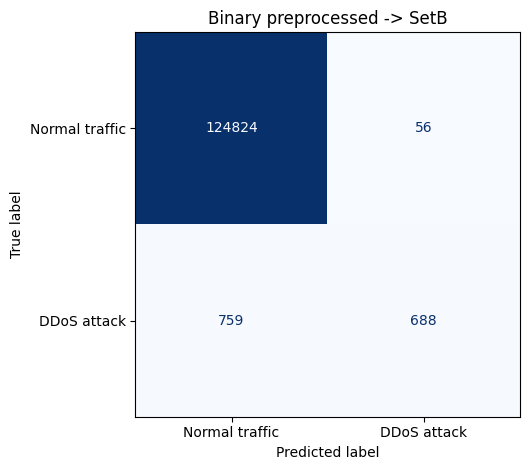

Confusion matrix: binary SMOTE -> SetB


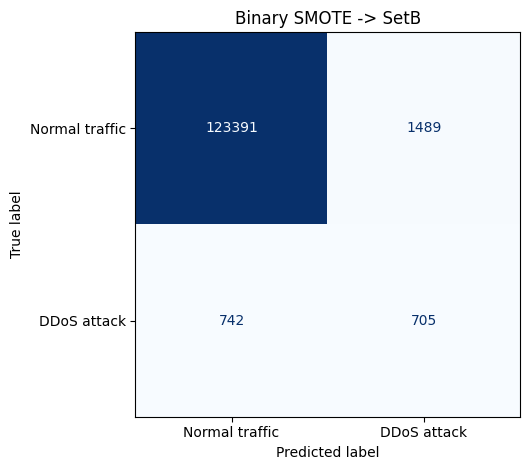


Saved model bundle: ddos-detection\models\binary_baseline_preprocessed.joblib
Saved model parameters: ddos-detection\models\binary_baseline_preprocessed_params.json


In [22]:
# Binary-only experiment: keep only Normal traffic vs DDoS attack
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
 )

POS_LABEL = "DDoS attack"
NEG_LABEL = "Normal traffic"
KEEP_LABELS = {NEG_LABEL, POS_LABEL}


def _drop_suspicious(X, y):
    mask = y.isin(KEEP_LABELS)
    return X.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True)


def _binary_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_ddos": f1_score(y_true, y_pred, pos_label=POS_LABEL),
        "precision_ddos": precision_score(y_true, y_pred, pos_label=POS_LABEL),
        "recall_ddos": recall_score(y_true, y_pred, pos_label=POS_LABEL),
    }


def _plot_binary_cm(y_true, y_pred, title):
    labels = [NEG_LABEL, POS_LABEL]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(5.5, 4.8))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


if "build_baseline_model" not in globals():
    raise RuntimeError("Run cell 11 first to define build_baseline_model().")

# Ensure SetB preprocessed data is present.
if "setb_all" not in globals():
    setb_result = preprocess(["SCLDDoS2024_SetB"], out_dir="./ddos-detection/data_preprocessed_setb", verbose=False)
    setb_all = setb_result["all"].copy()

# SetA preprocessed train pool -> binary
pre_base = Path("./ddos-detection/data_preprocessed")
seta_train = pd.read_csv(pre_base / "train.csv")
seta_val = pd.read_csv(pre_base / "validation.csv")

X_seta_train_raw, y_seta_train = _split_xy_no_leak(seta_train, target_col="type")
X_seta_val_raw, y_seta_val = _split_xy_no_leak(seta_val, target_col="type")
X_seta_pool_raw = pd.concat([X_seta_train_raw, X_seta_val_raw], ignore_index=True)
y_seta_pool = pd.concat([y_seta_train.reset_index(drop=True), y_seta_val.reset_index(drop=True)], ignore_index=True)
X_seta_pool_raw, y_seta_pool = _drop_suspicious(X_seta_pool_raw, y_seta_pool)

X_setb_raw, y_setb = _split_xy_no_leak(setb_all, target_col="type")
X_setb_raw, y_setb = _drop_suspicious(X_setb_raw, y_setb)

X_pre_bin_train = pd.get_dummies(X_seta_pool_raw)
X_setb_for_pre_bin = pd.get_dummies(X_setb_raw).reindex(columns=X_pre_bin_train.columns, fill_value=0)

pre_bin_model = build_baseline_model(random_state=42)
pre_bin_model.fit(X_pre_bin_train, y_seta_pool)
y_setb_pred_pre_bin = pre_bin_model.predict(X_setb_for_pre_bin)
pre_bin_metrics = _binary_metrics(y_setb, y_setb_pred_pre_bin)

# SetA preprocessed + SMOTE (binary) -> binary
counts = y_seta_pool.value_counts()
k_neighbors = min(5, counts.min() - 1)
smote_bin = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_bin_smote, y_bin_smote = smote_bin.fit_resample(X_pre_bin_train, y_seta_pool)

aug_bin_model = build_baseline_model(random_state=42)
aug_bin_model.fit(X_bin_smote, y_bin_smote)
y_setb_pred_aug_bin = aug_bin_model.predict(X_setb_for_pre_bin)
aug_bin_metrics = _binary_metrics(y_setb, y_setb_pred_aug_bin)

binary_compare_df = pd.DataFrame([
    {"train_source": "SetA preprocessed (binary)", **pre_bin_metrics},
    {"train_source": "SetA preprocessed + SMOTE (binary)", **aug_bin_metrics},
])

binary_delta_df = pd.DataFrame([
    {
        "delta_accuracy": aug_bin_metrics["accuracy"] - pre_bin_metrics["accuracy"],
        "delta_balanced_accuracy": aug_bin_metrics["balanced_accuracy"] - pre_bin_metrics["balanced_accuracy"],
        "delta_f1_macro": aug_bin_metrics["f1_macro"] - pre_bin_metrics["f1_macro"],
        "delta_f1_ddos": aug_bin_metrics["f1_ddos"] - pre_bin_metrics["f1_ddos"],
        "delta_precision_ddos": aug_bin_metrics["precision_ddos"] - pre_bin_metrics["precision_ddos"],
        "delta_recall_ddos": aug_bin_metrics["recall_ddos"] - pre_bin_metrics["recall_ddos"],
    }
])

print("SetB holdout with Suspicious traffic removed (binary task):")
display(binary_compare_df)
print("\nDelta (binary SMOTE - binary preprocessed):")
display(binary_delta_df)

print("\nConfusion matrix: binary preprocessed -> SetB")
_plot_binary_cm(y_setb, y_setb_pred_pre_bin, "Binary preprocessed -> SetB")

print("Confusion matrix: binary SMOTE -> SetB")
_plot_binary_cm(y_setb, y_setb_pred_aug_bin, "Binary SMOTE -> SetB")

# Persist trained binary baseline model and its parameters.
model_dir = Path("./ddos-detection/models")
model_dir.mkdir(parents=True, exist_ok=True)

binary_model_bundle = {
    "model": pre_bin_model,
    "feature_columns": X_pre_bin_train.columns.tolist(),
    "labels": [NEG_LABEL, POS_LABEL],
}
model_bundle_path = model_dir / "binary_baseline_preprocessed.joblib"
params_path = model_dir / "binary_baseline_preprocessed_params.json"

joblib.dump(binary_model_bundle, model_bundle_path)
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(pre_bin_model.get_params(), f, indent=2)

print(f"\nSaved model bundle: {model_bundle_path}")
print(f"Saved model parameters: {params_path}")

Loaded model parameters (excerpt):
- n_estimators: 200
- max_depth: 18
- min_samples_leaf: 2
- class_weight: balanced_subsample
- random_state: 42
Saved: ddos-detection\data_preprocessed_setc\all_data.csv (129999 rows)
Saved: ddos-detection\data_preprocessed_setc\train.csv (90999 rows)
Saved: ddos-detection\data_preprocessed_setc\validation.csv (13000 rows)
Saved: ddos-detection\data_preprocessed_setc\test.csv (26000 rows)


,eval_dataset,accuracy,balanced_accuracy,f1_macro,f1_ddos,precision_ddos,recall_ddos
0,SetC binary (Normal vs DDoS),0.993422,0.67382,0.732591,0.468491,0.713178,0.348815



Confusion matrix: reloaded binary baseline -> SetC


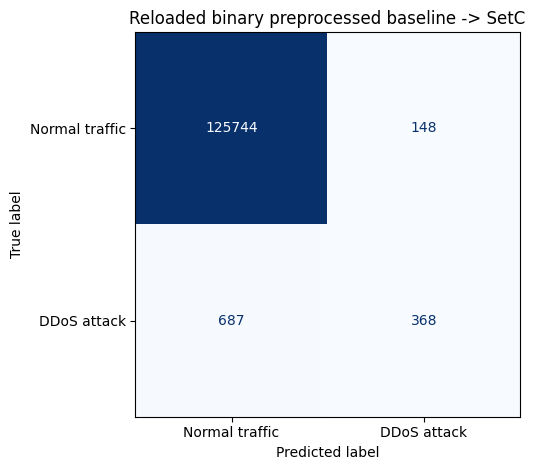

In [23]:
# Reload saved binary baseline model and evaluate on preprocessed SetC
from pathlib import Path
import json

import joblib
import pandas as pd

model_dir = Path("./ddos-detection/models")
model_bundle_path = model_dir / "binary_baseline_preprocessed.joblib"
params_path = model_dir / "binary_baseline_preprocessed_params.json"

if not model_bundle_path.exists() or not params_path.exists():
    raise FileNotFoundError("Run cell 16 first to train and save the binary baseline model files.")

with open(params_path, "r", encoding="utf-8") as f:
    loaded_params = json.load(f)
model_bundle = joblib.load(model_bundle_path)
loaded_model = model_bundle["model"]
feature_columns = model_bundle["feature_columns"]

print("Loaded model parameters (excerpt):")
for k in ["n_estimators", "max_depth", "min_samples_leaf", "class_weight", "random_state"]:
    print(f"- {k}: {loaded_params.get(k)}")

# Preprocess completely unused SetC
setc_result = preprocess(
    ["SCLDDoS2024_SetC"],
    out_dir="./ddos-detection/data_preprocessed_setc",
    verbose=False,
)
setc_all = setc_result["all"].copy()

X_setc_raw, y_setc = _split_xy_no_leak(setc_all, target_col="type")
X_setc_raw, y_setc = _drop_suspicious(X_setc_raw, y_setc)

X_setc_encoded = pd.get_dummies(X_setc_raw).reindex(columns=feature_columns, fill_value=0)
y_setc_pred = loaded_model.predict(X_setc_encoded)
setc_metrics = _binary_metrics(y_setc, y_setc_pred)

setc_results_df = pd.DataFrame([
    {"eval_dataset": "SetC binary (Normal vs DDoS)", **setc_metrics}
])
display(setc_results_df)

print("\nConfusion matrix: reloaded binary baseline -> SetC")
_plot_binary_cm(y_setc, y_setc_pred, "Reloaded binary preprocessed baseline -> SetC")

### Binary SMOTE with Partial Imbalance (SetA -> SetB)

Retry SMOTE in a binary setup while intentionally keeping class imbalance after resampling.

- Train: SetA (Normal traffic vs DDoS attack only)
- Evaluate: SetB (same binary filtering)
- Target post-SMOTE imbalance variants: Normal:DDoS = 2:1 and 3:1

Binary SetA train-pool class counts before SMOTE:
type
Normal traffic    99306
DDoS attack         741
Name: count, dtype: int64
Current minority/majority ratio (DDoS/Normal): 0.0075

SetB binary evaluation (SetA-trained, Suspicious dropped):


,method,target_normal_to_ddos,train_ddos_over_normal,accuracy,balanced_accuracy,f1_macro,f1_ddos,precision_ddos,recall_ddos
0,No SMOTE baseline,original,0.007462,0.993548,0.737509,0.812385,0.628024,0.924731,0.475466
1,SMOTE partial N:D=2:1,2:1,0.500000,0.987271,0.741506,0.731082,0.468605,0.449018,0.489979
2,SMOTE partial N:D=3:1,3:1,0.333333,0.986962,0.739984,0.727319,0.461237,0.437888,0.487215



Best by f1_ddos: No SMOTE baseline

Confusion matrix for best method on SetB:


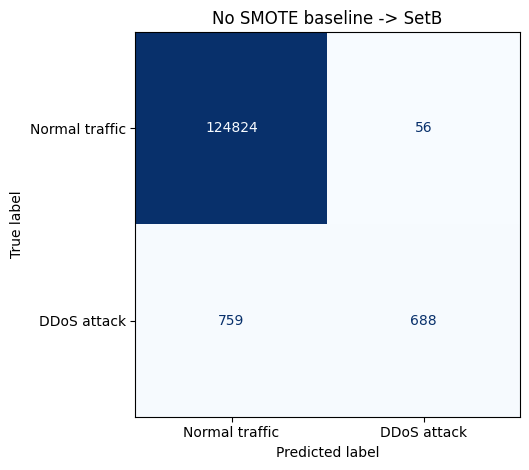

In [24]:
from pathlib import Path

import pandas as pd
from imblearn.over_sampling import SMOTE

if "build_baseline_model" not in globals():
    raise RuntimeError("Run cell 11 first to define build_baseline_model().")

if "_split_xy_no_leak" not in globals() or "_drop_suspicious" not in globals() or "_binary_metrics" not in globals():
    raise RuntimeError("Run cell 16 first to define binary helper functions.")

# Ensure SetB is available in preprocessed form.
if "setb_all" not in globals():
    setb_result = preprocess(["SCLDDoS2024_SetB"], out_dir="./ddos-detection/data_preprocessed_setb", verbose=False)
    setb_all = setb_result["all"].copy()

# Prepare binary train pool from SetA preprocessed data.
pre_base = Path("./ddos-detection/data_preprocessed")
seta_train = pd.read_csv(pre_base / "train.csv")
seta_val = pd.read_csv(pre_base / "validation.csv")

X_seta_train_raw, y_seta_train = _split_xy_no_leak(seta_train, target_col="type")
X_seta_val_raw, y_seta_val = _split_xy_no_leak(seta_val, target_col="type")
X_seta_pool_raw = pd.concat([X_seta_train_raw, X_seta_val_raw], ignore_index=True)
y_seta_pool = pd.concat([y_seta_train.reset_index(drop=True), y_seta_val.reset_index(drop=True)], ignore_index=True)
X_seta_pool_raw, y_seta_pool = _drop_suspicious(X_seta_pool_raw, y_seta_pool)

# Prepare binary SetB evaluation data.
X_setb_raw, y_setb = _split_xy_no_leak(setb_all, target_col="type")
X_setb_raw, y_setb = _drop_suspicious(X_setb_raw, y_setb)

X_train_bin = pd.get_dummies(X_seta_pool_raw)
X_setb_eval = pd.get_dummies(X_setb_raw).reindex(columns=X_train_bin.columns, fill_value=0)

counts_before = y_seta_pool.value_counts()
majority_count = int(counts_before[NEG_LABEL])
minority_count = int(counts_before[POS_LABEL])
minority_over_majority_before = minority_count / majority_count

print("Binary SetA train-pool class counts before SMOTE:")
print(counts_before)
print(f"Current minority/majority ratio (DDoS/Normal): {minority_over_majority_before:.4f}")

results_rows = []
predictions = {}

# Baseline (no SMOTE) for reference.
baseline_model = build_baseline_model(random_state=42)
baseline_model.fit(X_train_bin, y_seta_pool)
y_pred_baseline = baseline_model.predict(X_setb_eval)
results_rows.append({
    "method": "No SMOTE baseline",
    "target_normal_to_ddos": "original",
    "train_ddos_over_normal": minority_over_majority_before,
    **_binary_metrics(y_setb, y_pred_baseline),
})
predictions["No SMOTE baseline"] = y_pred_baseline

# Keep some imbalance intentionally: Normal:DDoS = 2:1 and 3:1.
for normal_to_ddos in [2.0, 3.0]:
    desired_ratio = 1.0 / normal_to_ddos  # SMOTE float expects minority/majority ratio.

    if desired_ratio <= minority_over_majority_before:
        print(
            f"Skipping N:D={normal_to_ddos:.1f}:1 because desired D/N={desired_ratio:.4f} "
            f"is not larger than current {minority_over_majority_before:.4f}."
        )
        continue

    k_neighbors = min(5, minority_count - 1)
    smote = SMOTE(sampling_strategy=desired_ratio, random_state=42, k_neighbors=k_neighbors)
    X_res, y_res = smote.fit_resample(X_train_bin, y_seta_pool)

    counts_after = y_res.value_counts()
    actual_ratio = counts_after[POS_LABEL] / counts_after[NEG_LABEL]

    model = build_baseline_model(random_state=42)
    model.fit(X_res, y_res)
    y_pred = model.predict(X_setb_eval)

    label = f"SMOTE partial N:D={normal_to_ddos:.0f}:1"
    results_rows.append({
        "method": label,
        "target_normal_to_ddos": f"{normal_to_ddos:.0f}:1",
        "train_ddos_over_normal": actual_ratio,
        **_binary_metrics(y_setb, y_pred),
    })
    predictions[label] = y_pred

results_df = pd.DataFrame(results_rows).sort_values(by=["f1_ddos", "balanced_accuracy"], ascending=False)
print("\nSetB binary evaluation (SetA-trained, Suspicious dropped):")
display(results_df)

best_method = results_df.iloc[0]["method"]
print(f"\nBest by f1_ddos: {best_method}")

print("\nConfusion matrix for best method on SetB:")
_plot_binary_cm(y_setb, predictions[best_method], f"{best_method} -> SetB")